# Train Log Analysis


In [ ]:
main_experiment_name = "core_experiments"
sub_experiment_name  = "full_routing"
dataset_name         = "sst2"
model_name           = "cats"
routing_type         = "carson"
run_name             = "run_002"

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

ROOT    = Path().resolve().parent.parent.parent
LOG_DIR = ROOT / 'logs' / main_experiment_name / sub_experiment_name / dataset_name / model_name / routing_type / run_name
OUT_DIR = Path().resolve() / main_experiment_name / sub_experiment_name / dataset_name / model_name / routing_type / run_name
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = LOG_DIR / 'train_log.csv'
assert CSV_PATH.exists(), f'train_log.csv not found at: {CSV_PATH}'

df     = pd.read_csv(CSV_PATH)
EPOCHS = df['epoch'].values

sns.set_theme(style='whitegrid', palette='tab10')
TITLE_TAG = f'{main_experiment_name} / {sub_experiment_name} / {dataset_name} / {routing_type} / {run_name}'

def save(fig, name):
    path = OUT_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'saved -> {path}')

print(f'Loaded {len(df)} epochs from: {CSV_PATH}')
print(f'Outputs -> {OUT_DIR}')

Loaded 8 epochs from: C:\Users\Zohoor Almalki\Projects\‏‏CATS\logs\core_experiments\full_routing\sst2\cats\carson\run_002\train_log.csv
Outputs -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002


In [ ]:
# Save train_log.csv to results/ (logs/ is git-ignored)
_save_path = OUT_DIR / 'train_log.csv'
df.to_csv(_save_path, index=False)
print(f'Saved  ->  {_save_path}')
display(df)

## 1 . Standard Training Curves

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\1a_loss.png


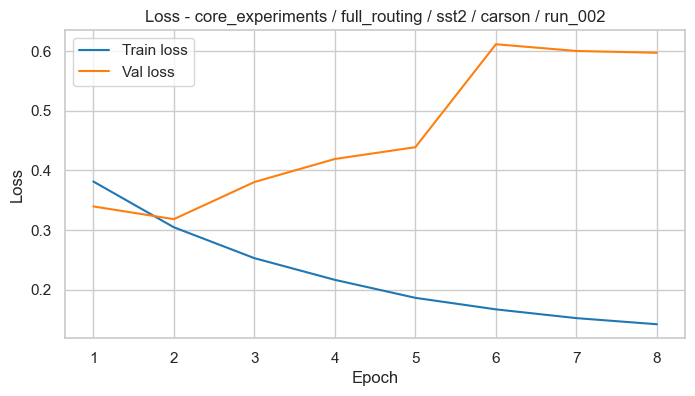

In [5]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_loss'], label='Train loss')
ax.plot(EPOCHS, df['val_loss'],   label='Val loss')
ax.set(xlabel='Epoch', ylabel='Loss', title=f'Loss - {TITLE_TAG}')
ax.legend(); save(fig,'1a_loss'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\1b_accuracy.png


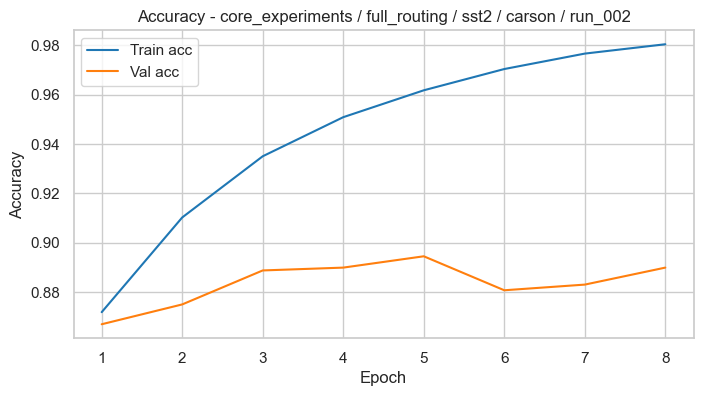

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_acc'], label='Train acc')
ax.plot(EPOCHS, df['val_acc'],   label='Val acc')
ax.set(xlabel='Epoch', ylabel='Accuracy', title=f'Accuracy - {TITLE_TAG}')
ax.legend(); save(fig,'1b_accuracy'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\1c_f1.png


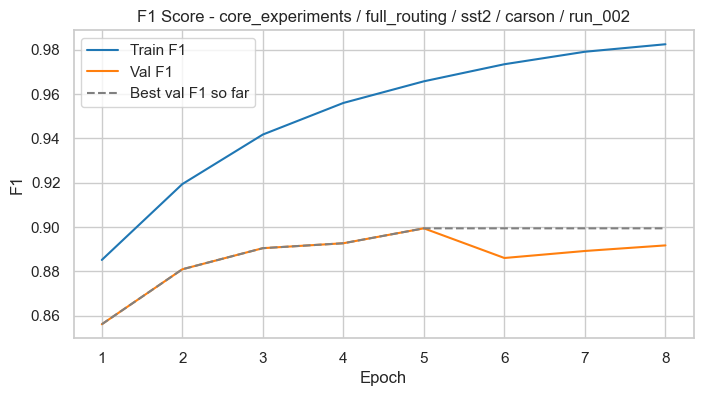

In [7]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_f1'],           label='Train F1')
ax.plot(EPOCHS, df['val_f1'],             label='Val F1')
ax.plot(EPOCHS, df['best_val_f1_so_far'], label='Best val F1 so far', linestyle='--', color='grey')
ax.set(xlabel='Epoch', ylabel='F1', title=f'F1 Score - {TITLE_TAG}')
ax.legend(); save(fig,'1c_f1'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\1d_precision_recall.png


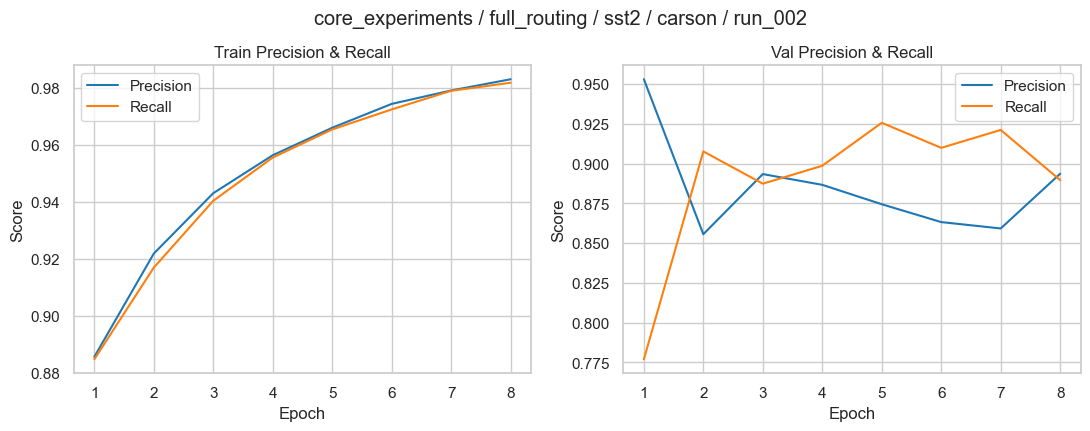

In [8]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes, ['train','val']):
    ax.plot(EPOCHS, df[f'{split}_precision'], label='Precision')
    ax.plot(EPOCHS, df[f'{split}_recall'],    label='Recall')
    ax.set(xlabel='Epoch', ylabel='Score', title=split.capitalize()+' Precision & Recall')
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'1d_precision_recall'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\1e_loss_decomposition.png


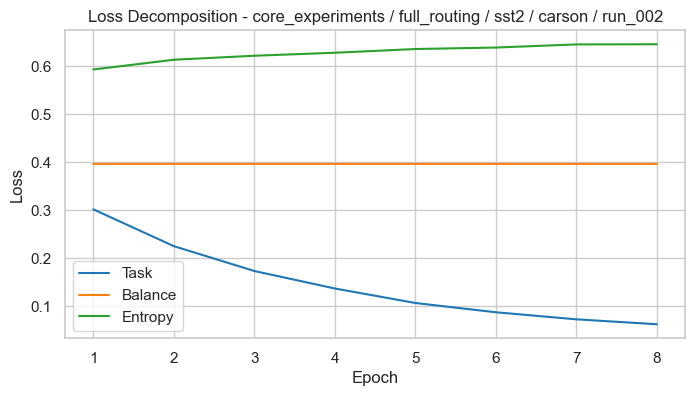

In [9]:
fig, ax = plt.subplots(figsize=(8,4))
for col, label in [('train_task_loss','Task'),('train_balance_loss','Balance'),('train_entropy_loss','Entropy')]:
    if col in df.columns:
        ax.plot(EPOCHS, df[col], label=label)
ax.set(xlabel='Epoch', ylabel='Loss', title=f'Loss Decomposition - {TITLE_TAG}')
ax.legend(); save(fig,'1e_loss_decomposition'); plt.show()


## 2 . Spiking Activity

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\2a_firing_rate.png


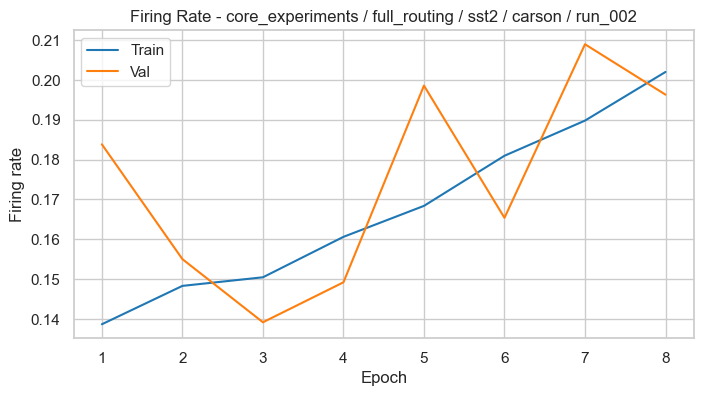

In [10]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_firing_rate'], label='Train')
ax.plot(EPOCHS, df['val_firing_rate'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Firing rate', title=f'Firing Rate - {TITLE_TAG}')
ax.legend(); save(fig,'2a_firing_rate'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\2b_spikes_per_sample_token.png


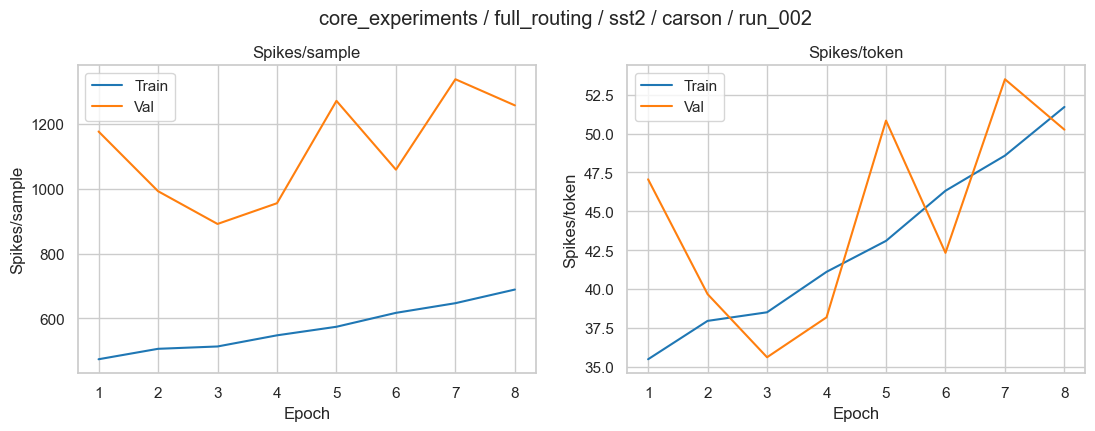

In [11]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, metric, ylabel in zip(axes,['spikes_per_sample','spikes_per_token'],['Spikes/sample','Spikes/token']):
    ax.plot(EPOCHS, df[f'train_{metric}'], label='Train')
    ax.plot(EPOCHS, df[f'val_{metric}'],   label='Val')
    ax.set(xlabel='Epoch', ylabel=ylabel, title=ylabel)
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'2b_spikes_per_sample_token'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\2c_exc_inh_firing_rate.png


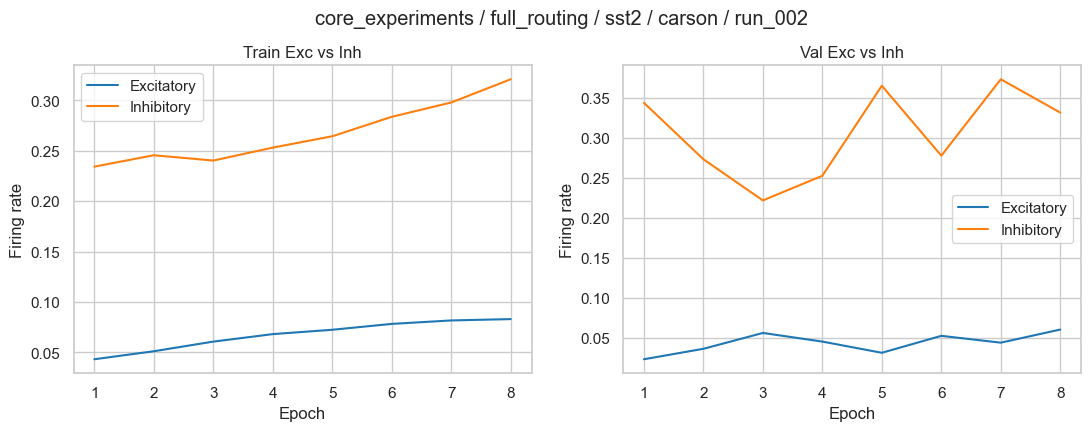

In [12]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    ax.plot(EPOCHS, df[f'{split}_exc_firing_rate'], label='Excitatory')
    ax.plot(EPOCHS, df[f'{split}_inh_firing_rate'], label='Inhibitory')
    ax.set(xlabel='Epoch', ylabel='Firing rate', title=split.capitalize()+' Exc vs Inh')
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'2c_exc_inh_firing_rate'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\2d_exc_inh_diff.png


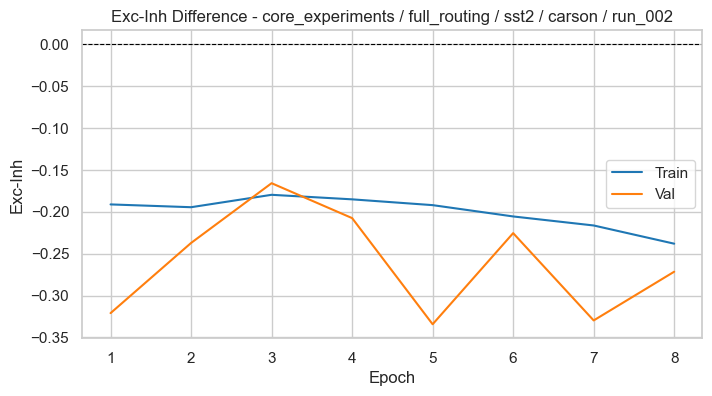

In [13]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_exc_inh_diff'], label='Train')
ax.plot(EPOCHS, df['val_exc_inh_diff'],   label='Val')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='Epoch', ylabel='Exc-Inh', title=f'Exc-Inh Difference - {TITLE_TAG}')
ax.legend(); save(fig,'2d_exc_inh_diff'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\2e_total_spikes.png


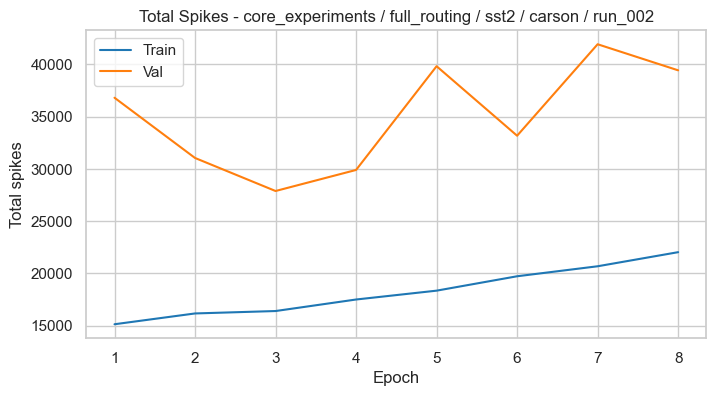

In [14]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_total_spikes'], label='Train')
ax.plot(EPOCHS, df['val_total_spikes'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Total spikes', title=f'Total Spikes - {TITLE_TAG}')
ax.legend(); save(fig,'2e_total_spikes'); plt.show()


## 3 . Routing Dynamics

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\3a_routing_entropy.png


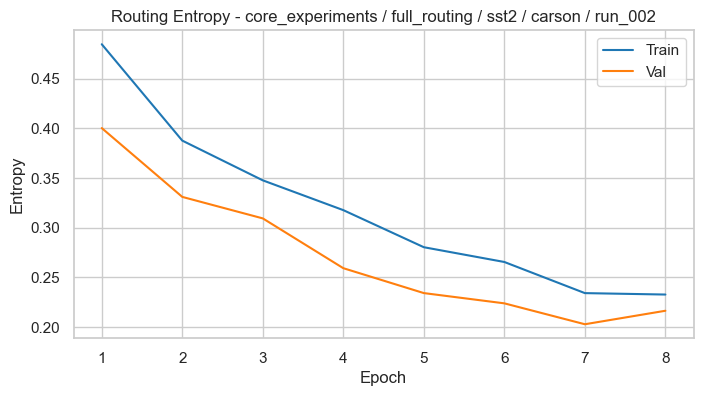

In [15]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_routing_entropy'], label='Train')
ax.plot(EPOCHS, df['val_routing_entropy'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Entropy', title=f'Routing Entropy - {TITLE_TAG}')
ax.legend(); save(fig,'3a_routing_entropy'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\3b_routing_confidence.png


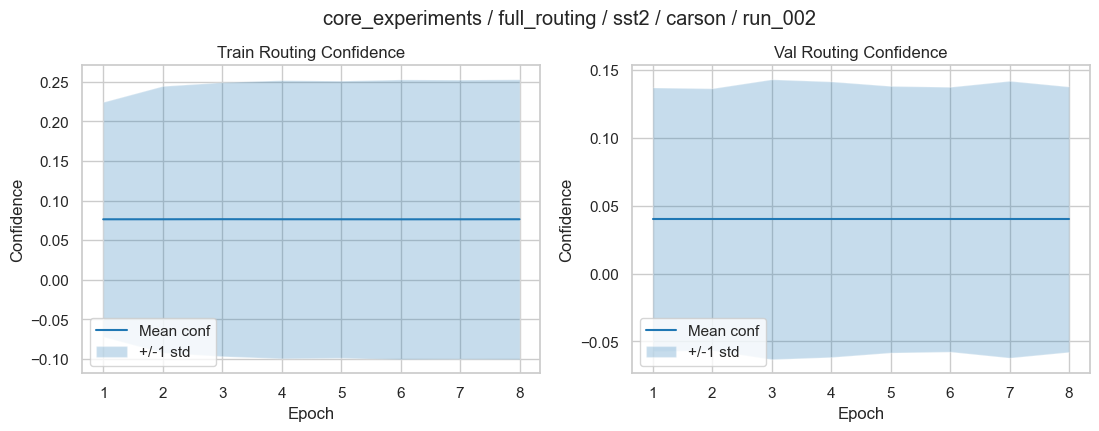

In [16]:
if 'train_routing_conf_mean' in df.columns:
    fig, axes = plt.subplots(1,2,figsize=(13,4))
    for ax, split in zip(axes,['train','val']):
        mean = df[f'{split}_routing_conf_mean']
        std  = df[f'{split}_routing_conf_std']
        ax.plot(EPOCHS, mean, label='Mean conf')
        ax.fill_between(EPOCHS, mean-std, mean+std, alpha=0.25, label='+/-1 std')
        ax.set(xlabel='Epoch', ylabel='Confidence', title=split.capitalize()+' Routing Confidence')
        ax.legend()
    fig.suptitle(TITLE_TAG, y=1.02)
    save(fig,'3b_routing_confidence'); plt.show()
else:
    print('Routing confidence not available for this routing type.')

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\3c_routing_variance.png


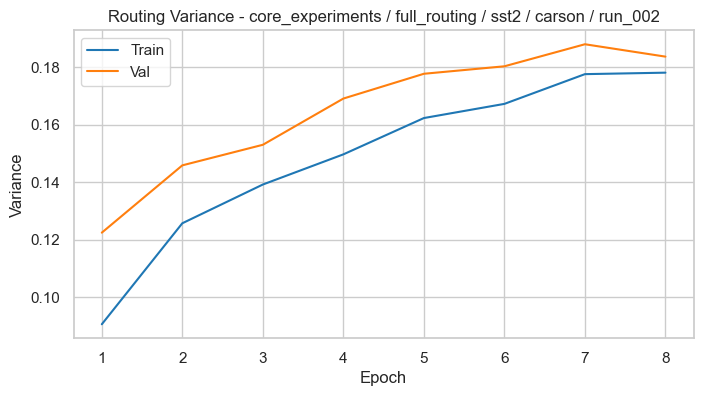

In [17]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_routing_variance'], label='Train')
ax.plot(EPOCHS, df['val_routing_variance'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Variance', title=f'Routing Variance - {TITLE_TAG}')
ax.legend(); save(fig,'3c_routing_variance'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\3d_usage_fraction.png


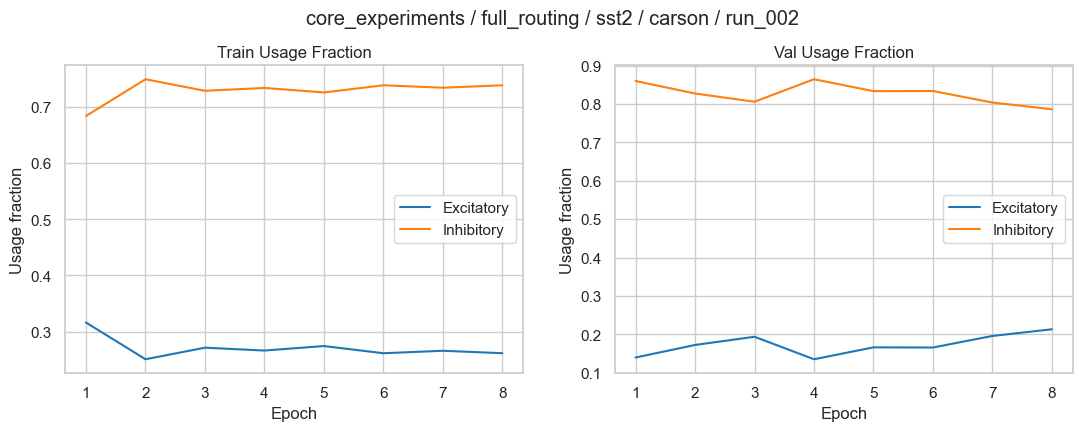

In [18]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    ax.plot(EPOCHS, df[f'{split}_exc_usage_fraction'], label='Excitatory')
    ax.plot(EPOCHS, df[f'{split}_inh_usage_fraction'], label='Inhibitory')
    ax.set(xlabel='Epoch', ylabel='Usage fraction', title=split.capitalize()+' Usage Fraction')
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'3d_usage_fraction'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\3e_dominance_fraction.png


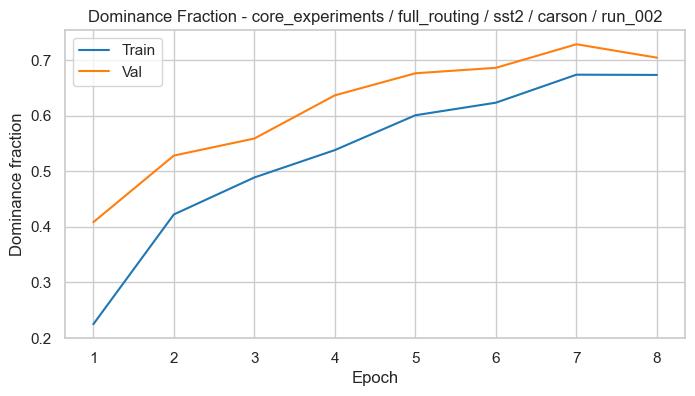

In [19]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_dominance_fraction'], label='Train')
ax.plot(EPOCHS, df['val_dominance_fraction'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Dominance fraction', title=f'Dominance Fraction - {TITLE_TAG}')
ax.legend(); save(fig,'3e_dominance_fraction'); plt.show()


## 4 . Weight Dynamics

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\4a_weight_means.png


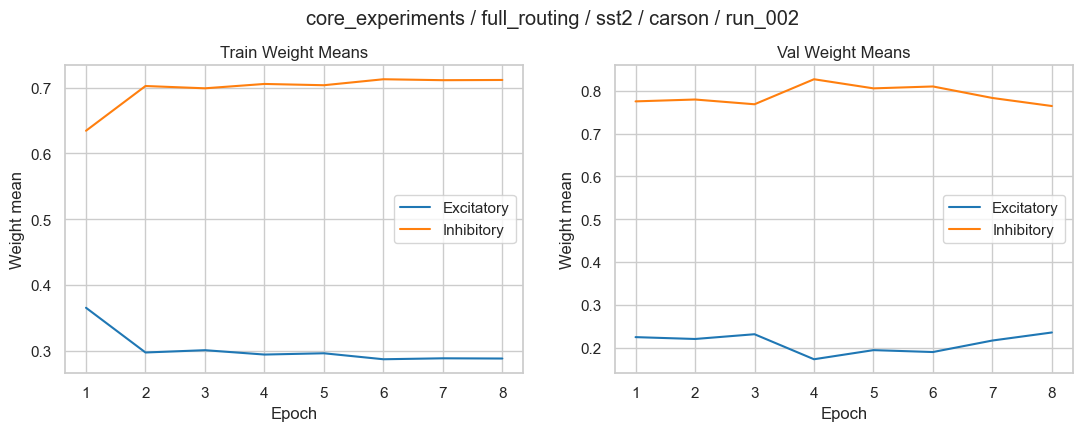

In [20]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    ax.plot(EPOCHS, df[f'{split}_exc_weight_mean'], label='Excitatory')
    ax.plot(EPOCHS, df[f'{split}_inh_weight_mean'], label='Inhibitory')
    ax.set(xlabel='Epoch', ylabel='Weight mean', title=split.capitalize()+' Weight Means')
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'4a_weight_means'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\4b_exc_inh_balance.png


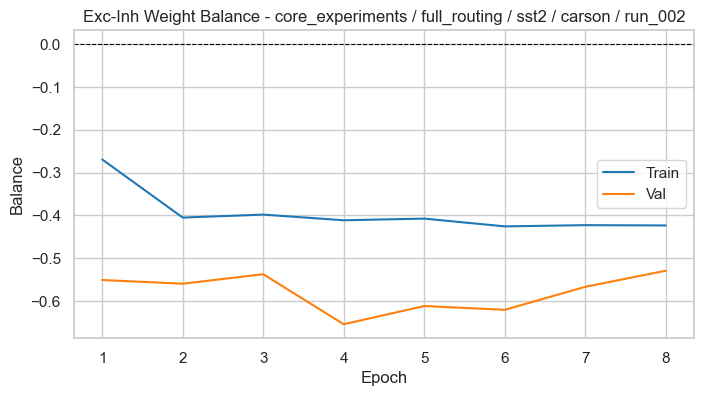

In [21]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_exc_inh_balance'], label='Train')
ax.plot(EPOCHS, df['val_exc_inh_balance'],   label='Val')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='Epoch', ylabel='Balance', title=f'Exc-Inh Weight Balance - {TITLE_TAG}')
ax.legend(); save(fig,'4b_exc_inh_balance'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\4c_weight_gap.png


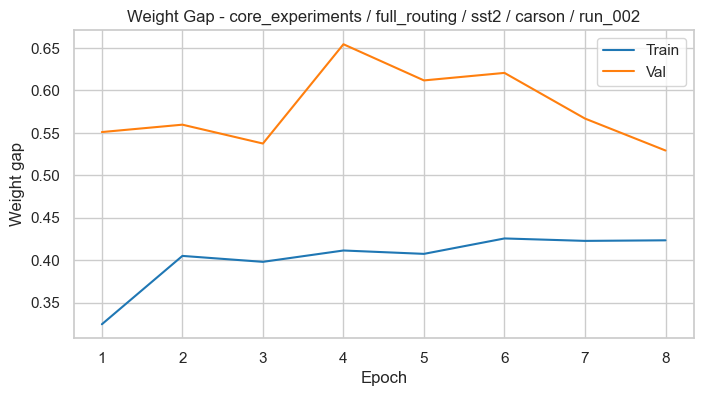

In [22]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_weight_gap'], label='Train')
ax.plot(EPOCHS, df['val_weight_gap'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Weight gap', title=f'Weight Gap - {TITLE_TAG}')
ax.legend(); save(fig,'4c_weight_gap'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\4d_weight_std.png


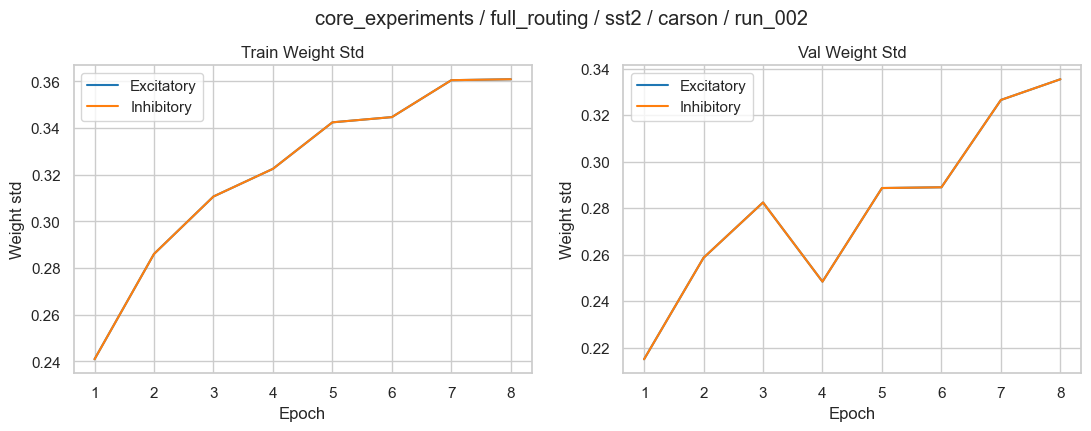

In [23]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    ax.plot(EPOCHS, df[f'{split}_exc_weight_std'], label='Excitatory')
    ax.plot(EPOCHS, df[f'{split}_inh_weight_std'], label='Inhibitory')
    ax.set(xlabel='Epoch', ylabel='Weight std', title=split.capitalize()+' Weight Std')
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'4d_weight_std'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\4e_max_weight_mean.png


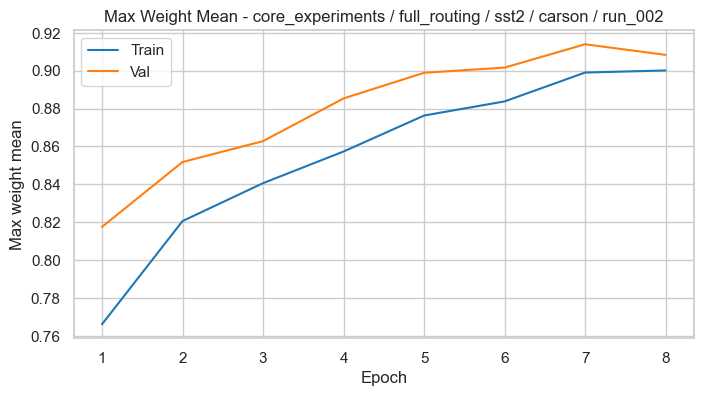

In [24]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_max_weight_mean'], label='Train')
ax.plot(EPOCHS, df['val_max_weight_mean'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Max weight mean', title=f'Max Weight Mean - {TITLE_TAG}')
ax.legend(); save(fig,'4e_max_weight_mean'); plt.show()


## 5 . Threshold Dynamics

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\5a_base_threshold.png


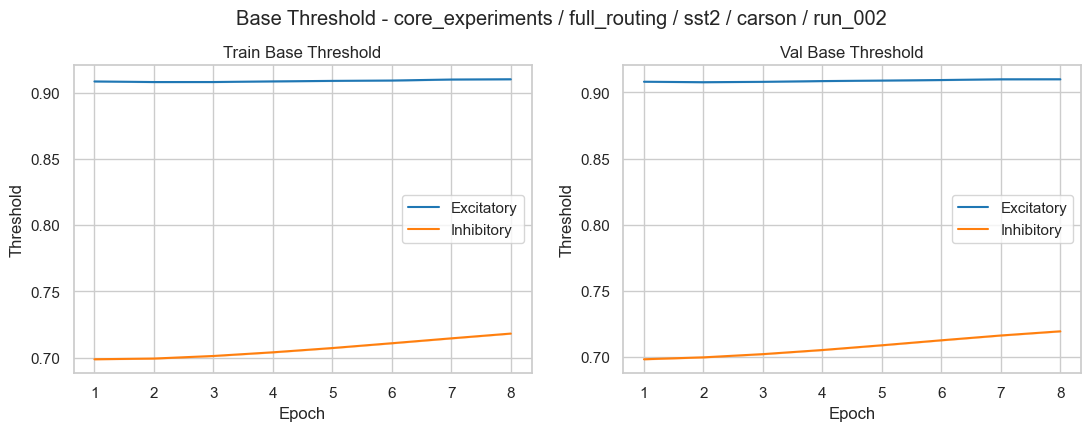

In [25]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    for label, prefix, color in [('Excitatory','exc','tab:blue'),('Inhibitory','inh','tab:orange')]:
        mean = df[f'{split}_{prefix}_threshold_mean']
        std  = df[f'{split}_{prefix}_threshold_std']
        ax.plot(EPOCHS, mean, label=label, color=color)
        ax.fill_between(EPOCHS, mean-std, mean+std, alpha=0.2, color=color)
    ax.set(xlabel='Epoch', ylabel='Threshold', title=split.capitalize()+' Base Threshold')
    ax.legend()
fig.suptitle('Base Threshold - '+TITLE_TAG, y=1.02)
save(fig,'5a_base_threshold'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\5b_effective_threshold.png


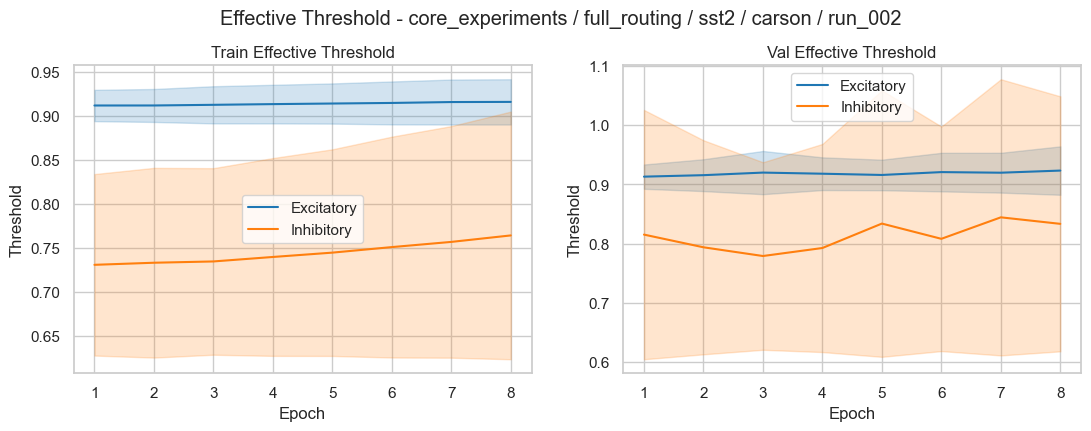

In [26]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    for label, prefix, color in [('Excitatory','exc','tab:blue'),('Inhibitory','inh','tab:orange')]:
        mean = df[f'{split}_{prefix}_effective_threshold_mean']
        std  = df[f'{split}_{prefix}_effective_threshold_std']
        ax.plot(EPOCHS, mean, label=label, color=color)
        ax.fill_between(EPOCHS, mean-std, mean+std, alpha=0.2, color=color)
    ax.set(xlabel='Epoch', ylabel='Threshold', title=split.capitalize()+' Effective Threshold')
    ax.legend()
fig.suptitle('Effective Threshold - '+TITLE_TAG, y=1.02)
save(fig,'5b_effective_threshold'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\5c_adaptive_threshold.png


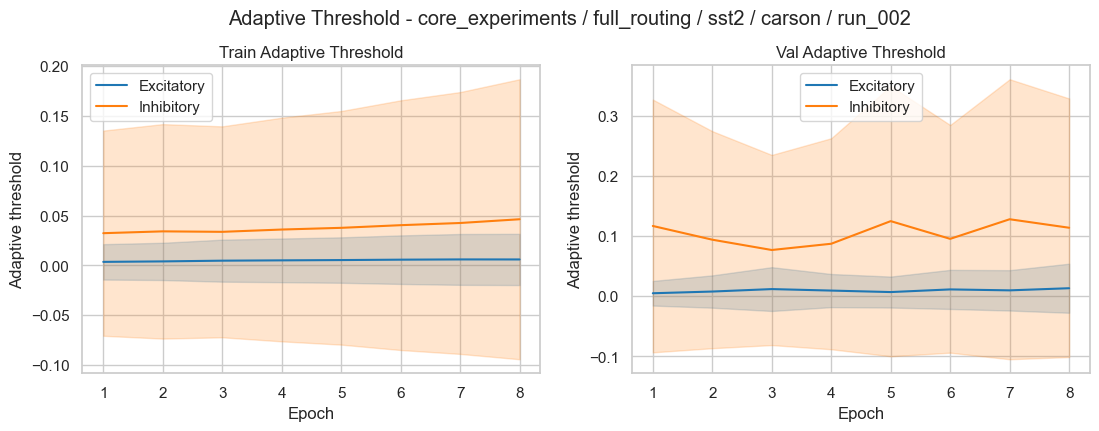

In [27]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    for label, prefix, color in [('Excitatory','exc','tab:blue'),('Inhibitory','inh','tab:orange')]:
        mean = df[f'{split}_{prefix}_adaptive_threshold_mean']
        std  = df[f'{split}_{prefix}_adaptive_threshold_std']
        ax.plot(EPOCHS, mean, label=label, color=color)
        ax.fill_between(EPOCHS, mean-std, mean+std, alpha=0.2, color=color)
    ax.set(xlabel='Epoch', ylabel='Adaptive threshold', title=split.capitalize()+' Adaptive Threshold')
    ax.legend()
fig.suptitle('Adaptive Threshold - '+TITLE_TAG, y=1.02)
save(fig,'5c_adaptive_threshold'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\5d_threshold_components.png


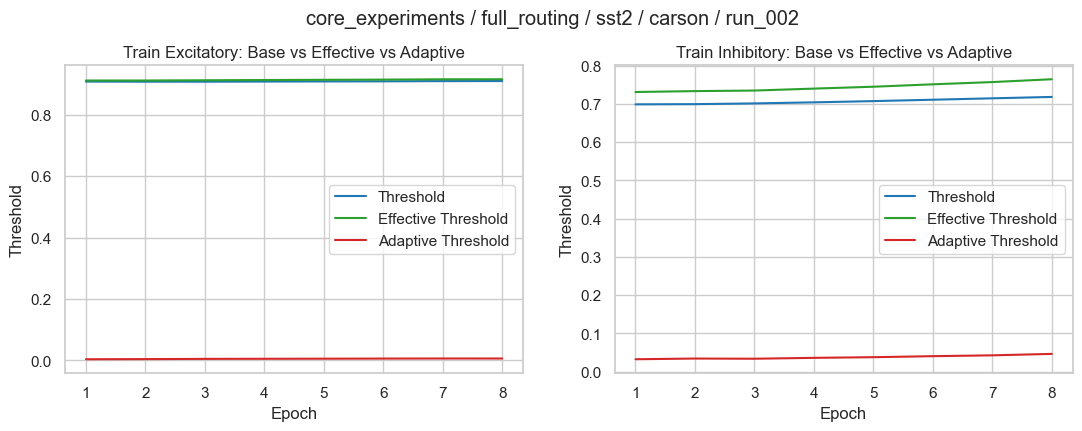

In [28]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, prefix, ttl in zip(axes,['exc','inh'],['Excitatory','Inhibitory']):
    for kind, color in [('threshold','tab:blue'),('effective_threshold','tab:green'),('adaptive_threshold','tab:red')]:
        ax.plot(EPOCHS, df[f'train_{prefix}_{kind}_mean'], label=kind.replace('_',' ').title(), color=color)
    ax.set(xlabel='Epoch', ylabel='Threshold', title='Train '+ttl+': Base vs Effective vs Adaptive')
    ax.legend()
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'5d_threshold_components'); plt.show()


## 6 . Temporal Dynamics (Tau)

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\6a_tau.png


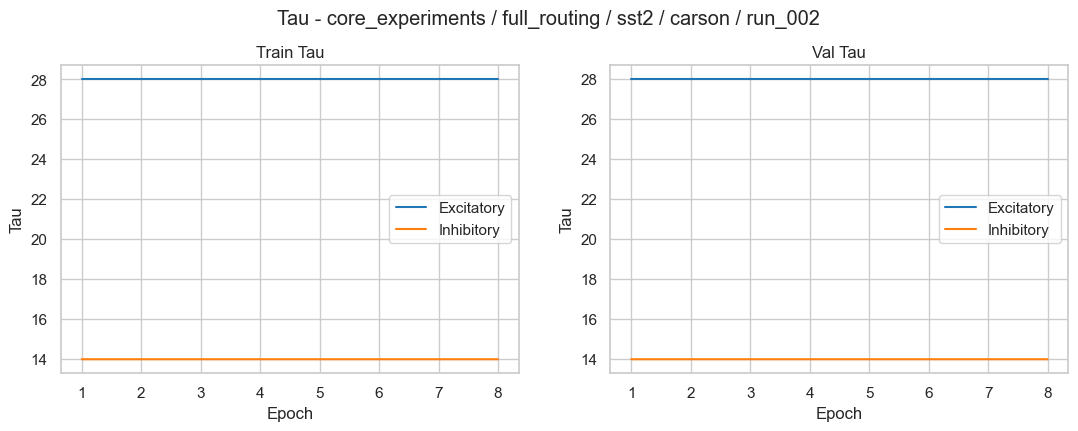

In [29]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, split in zip(axes,['train','val']):
    for label, prefix, color in [('Excitatory','exc','tab:blue'),('Inhibitory','inh','tab:orange')]:
        mean = df[f'{split}_{prefix}_tau_mean']
        std  = df[f'{split}_{prefix}_tau_std']
        ax.plot(EPOCHS, mean, label=label, color=color)
        if std.sum() > 0:
            ax.fill_between(EPOCHS, mean-std, mean+std, alpha=0.2, color=color)
    ax.set(xlabel='Epoch', ylabel='Tau', title=split.capitalize()+' Tau')
    ax.legend()
fig.suptitle('Tau - '+TITLE_TAG, y=1.02)
save(fig,'6a_tau'); plt.show()


## 7 . Speed & Efficiency

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\7a_epoch_time.png


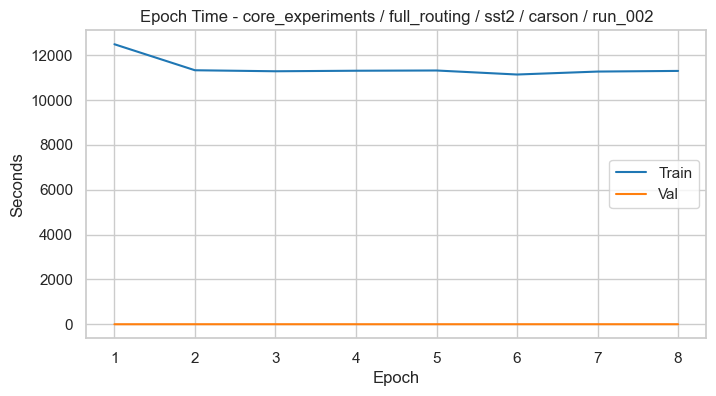

In [30]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_epoch_time_sec'], label='Train')
ax.plot(EPOCHS, df['val_epoch_time_sec'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Seconds', title=f'Epoch Time - {TITLE_TAG}')
ax.legend(); save(fig,'7a_epoch_time'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\7b_throughput.png


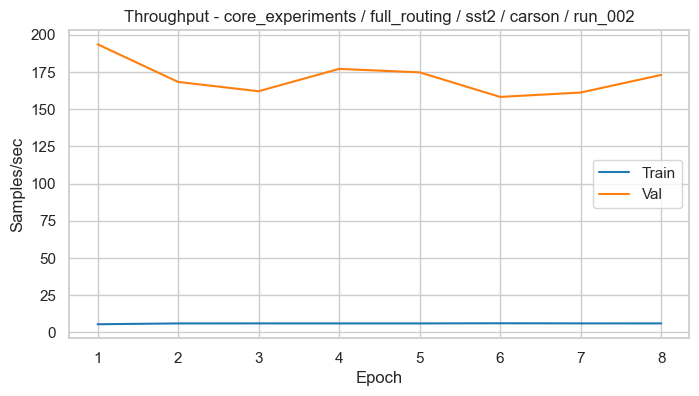

In [31]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_samples_per_sec'], label='Train')
ax.plot(EPOCHS, df['val_samples_per_sec'],   label='Val')
ax.set(xlabel='Epoch', ylabel='Samples/sec', title=f'Throughput - {TITLE_TAG}')
ax.legend(); save(fig,'7b_throughput'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\7c_fwd_bwd_time.png


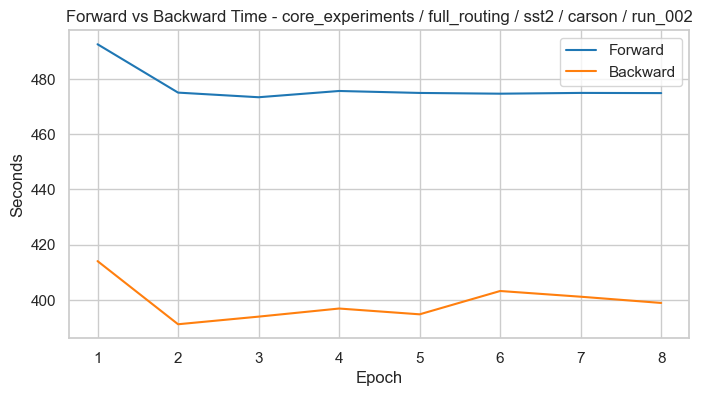

In [32]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_forward_time_sec'],  label='Forward')
ax.plot(EPOCHS, df['train_backward_time_sec'], label='Backward')
ax.set(xlabel='Epoch', ylabel='Seconds', title=f'Forward vs Backward Time - {TITLE_TAG}')
ax.legend(); save(fig,'7c_fwd_bwd_time'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\7d_gpu_memory.png


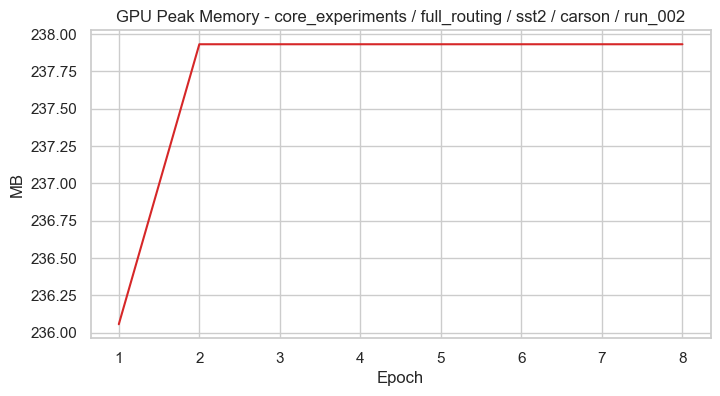

In [33]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['gpu_peak_mem_mb'], color='tab:red')
ax.set(xlabel='Epoch', ylabel='MB', title=f'GPU Peak Memory - {TITLE_TAG}')
save(fig,'7d_gpu_memory'); plt.show()


## 8 . Correlation / Joint Analysis

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\8a_f1_vs_firing_rate.png


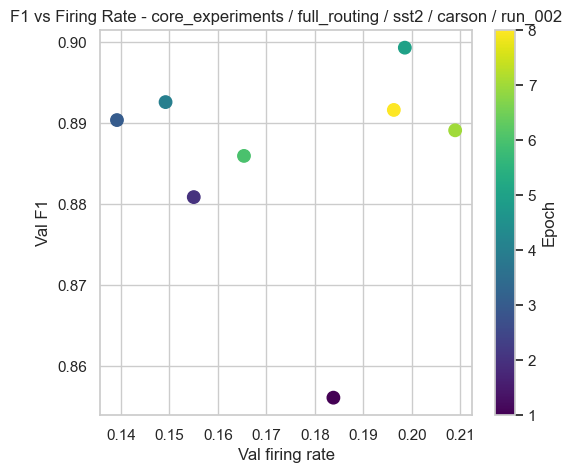

In [34]:
fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(df['val_firing_rate'], df['val_f1'], c=EPOCHS, cmap='viridis', s=80)
plt.colorbar(sc, ax=ax, label='Epoch')
ax.set(xlabel='Val firing rate', ylabel='Val F1', title=f'F1 vs Firing Rate - {TITLE_TAG}')
save(fig,'8a_f1_vs_firing_rate'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\8b_f1_vs_routing_entropy.png


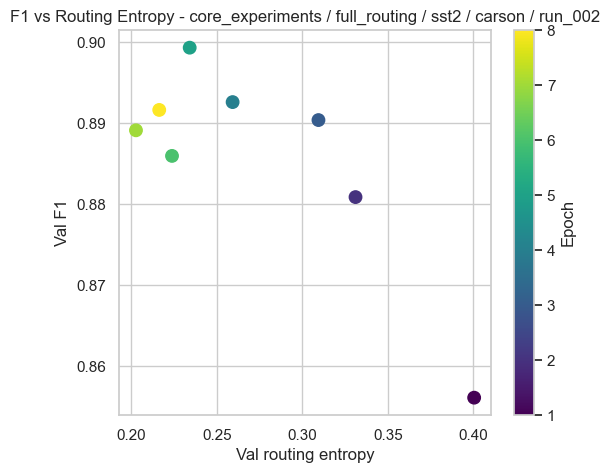

In [35]:
fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(df['val_routing_entropy'], df['val_f1'], c=EPOCHS, cmap='viridis', s=80)
plt.colorbar(sc, ax=ax, label='Epoch')
ax.set(xlabel='Val routing entropy', ylabel='Val F1', title=f'F1 vs Routing Entropy - {TITLE_TAG}')
save(fig,'8b_f1_vs_routing_entropy'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\8c_f1_vs_exc_inh_diff.png


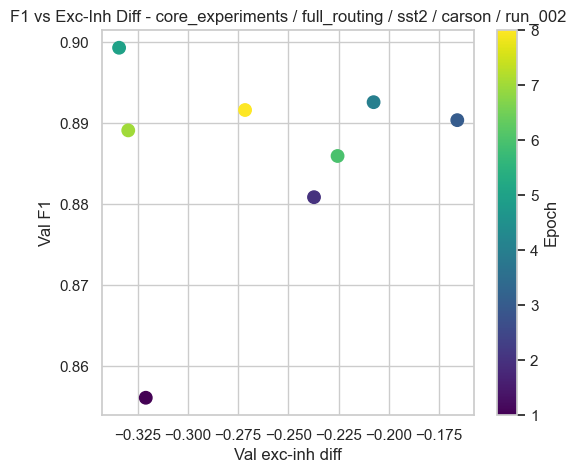

In [36]:
fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(df['val_exc_inh_diff'], df['val_f1'], c=EPOCHS, cmap='viridis', s=80)
plt.colorbar(sc, ax=ax, label='Epoch')
ax.set(xlabel='Val exc-inh diff', ylabel='Val F1', title=f'F1 vs Exc-Inh Diff - {TITLE_TAG}')
save(fig,'8c_f1_vs_exc_inh_diff'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\8d_f1_vs_loss_components.png


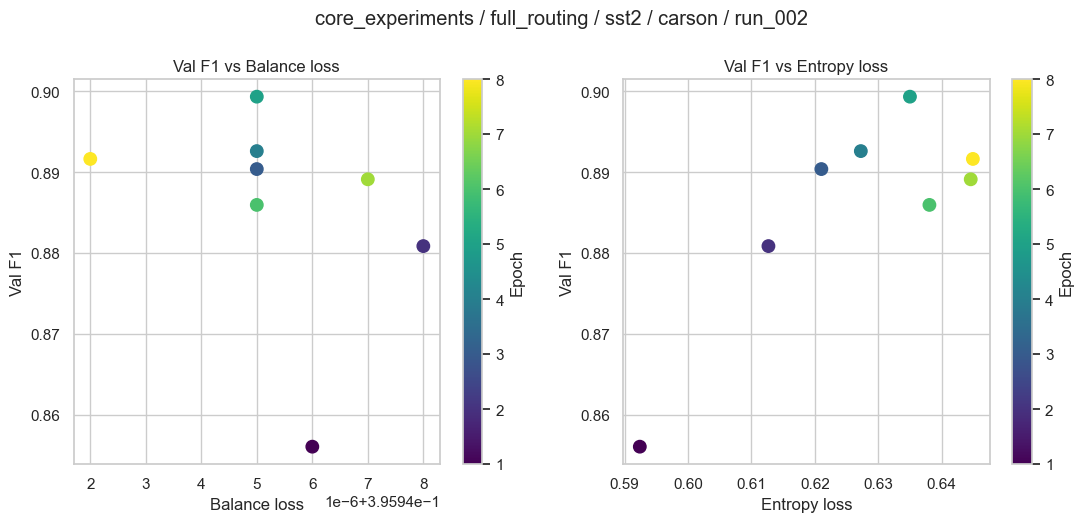

In [37]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, col, xlabel in zip(axes,['train_balance_loss','train_entropy_loss'],['Balance loss','Entropy loss']):
    if col in df.columns:
        sc = ax.scatter(df[col], df['val_f1'], c=EPOCHS, cmap='viridis', s=80)
        plt.colorbar(sc, ax=ax, label='Epoch')
        ax.set(xlabel=xlabel, ylabel='Val F1', title='Val F1 vs '+xlabel)
fig.suptitle(TITLE_TAG, y=1.02)
save(fig,'8d_f1_vs_loss_components'); plt.show()


c:\Users\Zohoor Almalki\Projects\‏‏CATS\analysis-env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Zohoor Almalki\Projects\‏‏CATS\analysis-env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\8e_correlation_heatmap.png


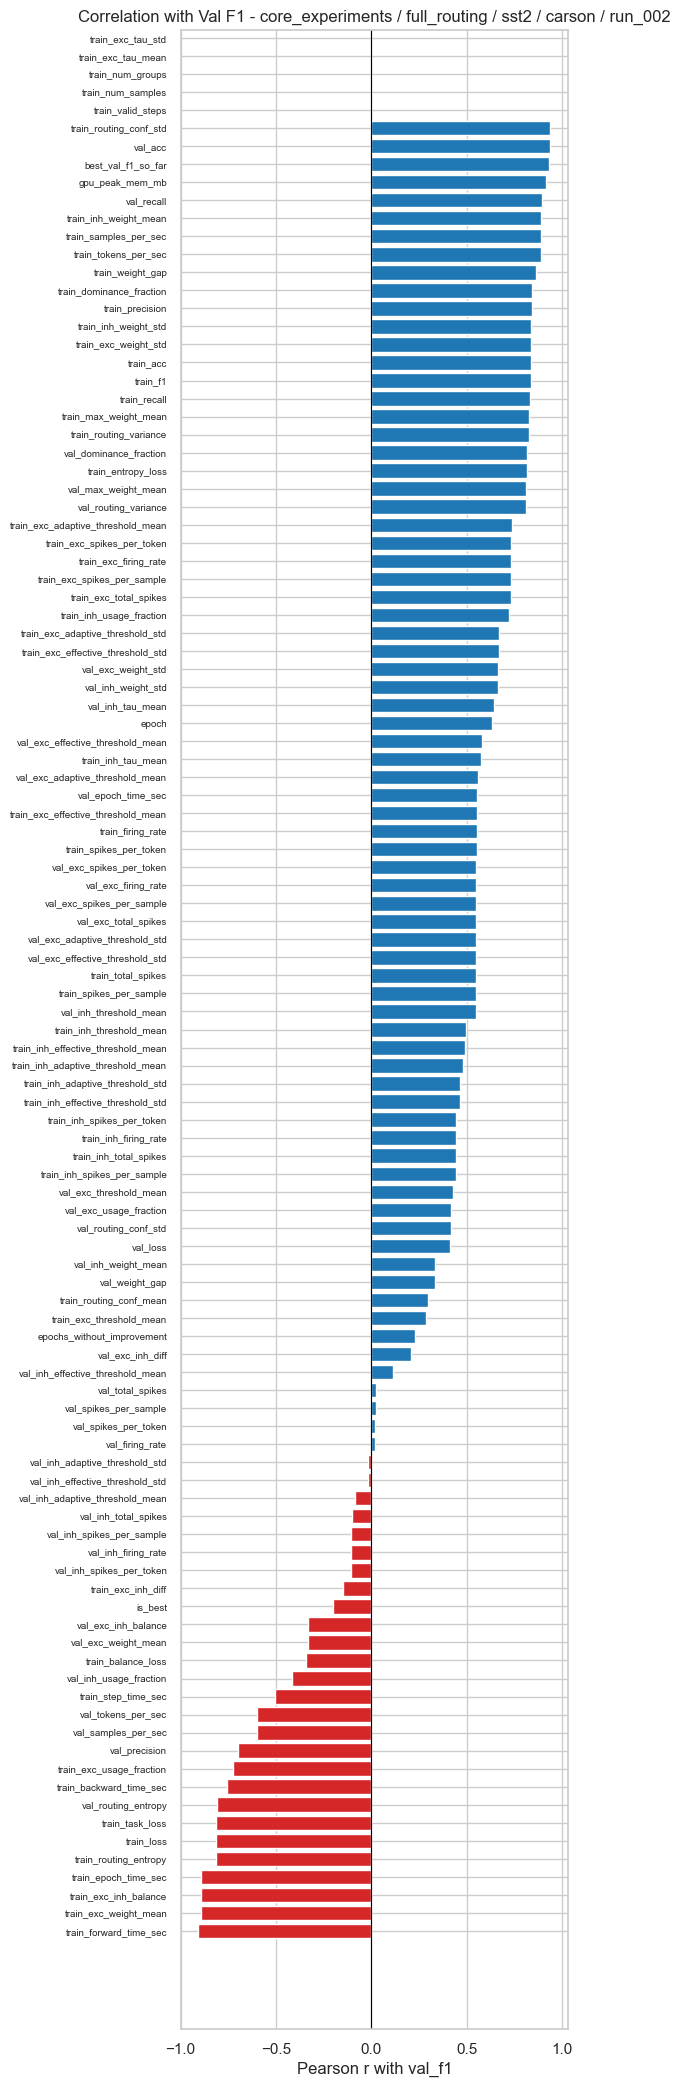

In [38]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corrwith(df['val_f1']).drop('val_f1', errors='ignore').sort_values()
fig, ax = plt.subplots(figsize=(5, max(6, len(corr)*0.22)))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(xlabel='Pearson r with val_f1', title='Correlation with Val F1 - '+TITLE_TAG)
ax.tick_params(axis='y', labelsize=7)
save(fig,'8e_correlation_heatmap'); plt.show()


## 9 . Train vs Val Gap (Generalisation)

saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\9a_f1_gap.png


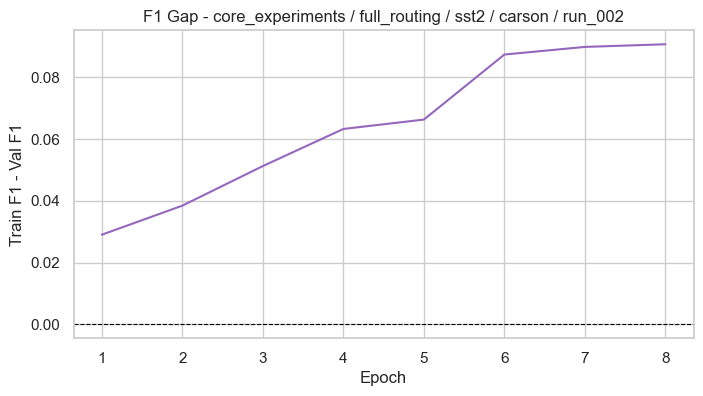

In [39]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_f1'] - df['val_f1'], color='tab:purple')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='Epoch', ylabel='Train F1 - Val F1', title=f'F1 Gap - {TITLE_TAG}')
save(fig,'9a_f1_gap'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\9b_loss_gap.png


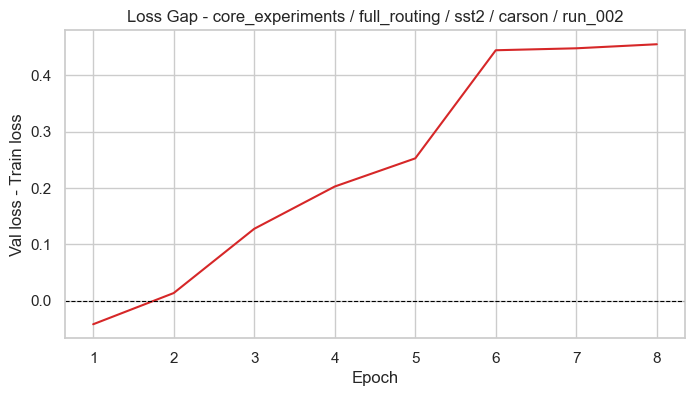

In [40]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['val_loss'] - df['train_loss'], color='tab:red')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='Epoch', ylabel='Val loss - Train loss', title=f'Loss Gap - {TITLE_TAG}')
save(fig,'9b_loss_gap'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\9c_firing_rate_gap.png


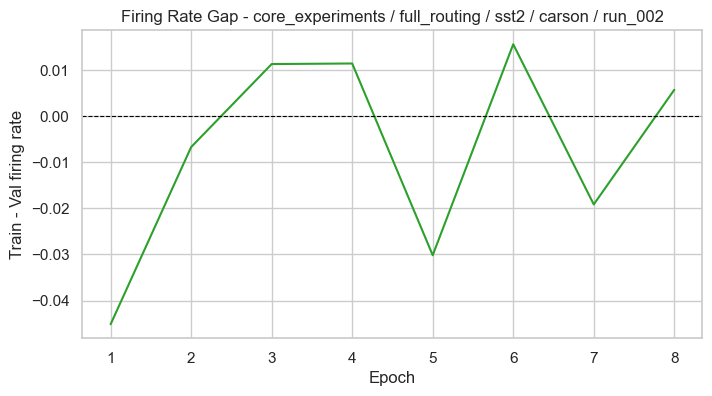

In [41]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_firing_rate'] - df['val_firing_rate'], color='tab:green')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='Epoch', ylabel='Train - Val firing rate', title=f'Firing Rate Gap - {TITLE_TAG}')
save(fig,'9c_firing_rate_gap'); plt.show()


saved -> C:\Users\Zohoor Almalki\Projects\‏‏CATS\results\core_experiments_analysis\sst2\core_experiments\full_routing\sst2\cats\carson\run_002\9d_routing_entropy_gap.png


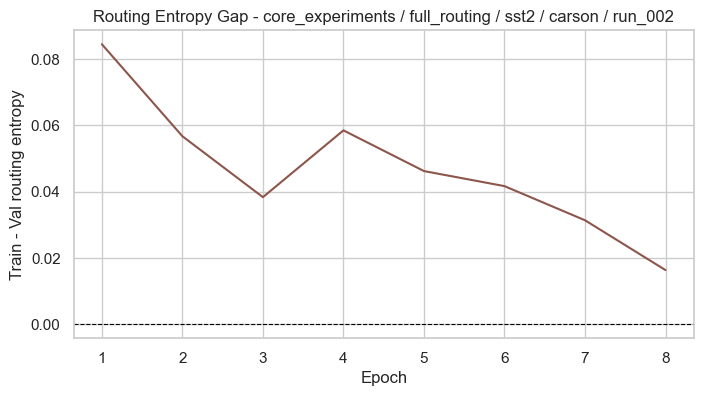

In [42]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(EPOCHS, df['train_routing_entropy'] - df['val_routing_entropy'], color='tab:brown')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='Epoch', ylabel='Train - Val routing entropy', title=f'Routing Entropy Gap - {TITLE_TAG}')
save(fig,'9d_routing_entropy_gap'); plt.show()


---
All plots saved to the output directory above.